https://www.kaggle.com/datasets/miadul/irrigation-water-requirement-prediction-dataset/data

In [140]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

df = pd.read_csv('irrigation_prediction.csv')
df = df.reset_index(drop=True)

In [141]:
list_kolom = df.columns.tolist()
print(list_kolom)
df.head(2)

['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.9,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.5,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium


In [142]:
df_data = df[['Soil_Moisture','Temperature_C','Humidity','Rainfall_mm','Previous_Irrigation_mm']]
print(df_data.columns)

Index(['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Previous_Irrigation_mm'],
      dtype='object')


In [143]:
# numeric_cols =['Soil_Moisture','Temperature_C','Humidity','Rainfall_mm','Previous_Irrigation_mm']
# for col in numeric_cols:
#     df_data[col] = pd.to_numeric(df_data[col], errors='coerce')
# df_data = df_data.reset_index(drop=True)
print("Jumlah data:", len(df_data))

Jumlah data: 10000


In [144]:
df['Previous_Irrigation_mm_diff'] = df['Previous_Irrigation_mm'].diff()
df = df.dropna()

In [145]:
df['lag1'] = df['Previous_Irrigation_mm'].shift(1)
df['lag2'] = df['Previous_Irrigation_mm'].shift(2)
df['lag3'] = df['Previous_Irrigation_mm'].shift(3)
df['lag4'] = df['Previous_Irrigation_mm'].shift(4)
df['lag5'] = df['Previous_Irrigation_mm'].shift(5)
df['lag6'] = df['Previous_Irrigation_mm_diff'].shift(6)
df['lag7'] = df['Previous_Irrigation_mm_diff'].shift(7)
df['lag8'] = df['Previous_Irrigation_mm_diff'].shift(8)

In [146]:
# rolling mean untuk bantu baca pola lokal
df['rolling_mean_3'] = df['Previous_Irrigation_mm'].rolling(3).mean()
df['rolling_mean_5'] = df['Previous_Irrigation_mm'].rolling(5).mean()
df['rolling_mean_10'] = df['Previous_Irrigation_mm'].rolling(10).mean()

In [147]:
df['rolling_std_5'] = df['Previous_Irrigation_mm_diff'].rolling(5).std()
# 🔥 perubahan cepat (momentum)
df['diff2'] = df['Previous_Irrigation_mm_diff'].diff(1)

# 🔥 max/min lokal
df['rolling_max_5'] = df['Previous_Irrigation_mm_diff'].rolling(5).max()
df['rolling_min_5'] = df['Previous_Irrigation_mm_diff'].rolling(5).min()

In [148]:
df = df.dropna().reset_index(drop=True)

In [149]:
X = df[['Soil_Moisture','Temperature_C','Humidity','Rainfall_mm','Previous_Irrigation_mm',
        'lag1','lag2','lag3','lag4','lag5','lag6','lag7','lag8',
        'rolling_mean_3','rolling_mean_5','rolling_mean_10',
        'rolling_std_5','rolling_max_5','rolling_min_5',
        'diff2']]
y = df['Previous_Irrigation_mm_diff'] 
print("\nUkuran data:")
print("X shape:", X.shape)
print("y shape:", y.shape)


Ukuran data:
X shape: (9990, 20)
y shape: (9990,)


In [150]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nData train:", X_train.shape, y_train.shape)
print("Data test :", X_test.shape, y_test.shape)


Data train: (7992, 20) (7992,)
Data test : (1998, 20) (1998,)


In [151]:
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='reg:squarederror',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [152]:
y_pred = model.predict(X_test)

In [153]:
# =========================================================
# 11. EVALUASI
# =========================================================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nHasil Evaluasi XGBoost")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)


Hasil Evaluasi XGBoost
MSE  : 1.2140939120905718
RMSE : 1.1018592977738
MAE  : 0.8257131952930379
R2   : 0.9994966336789097


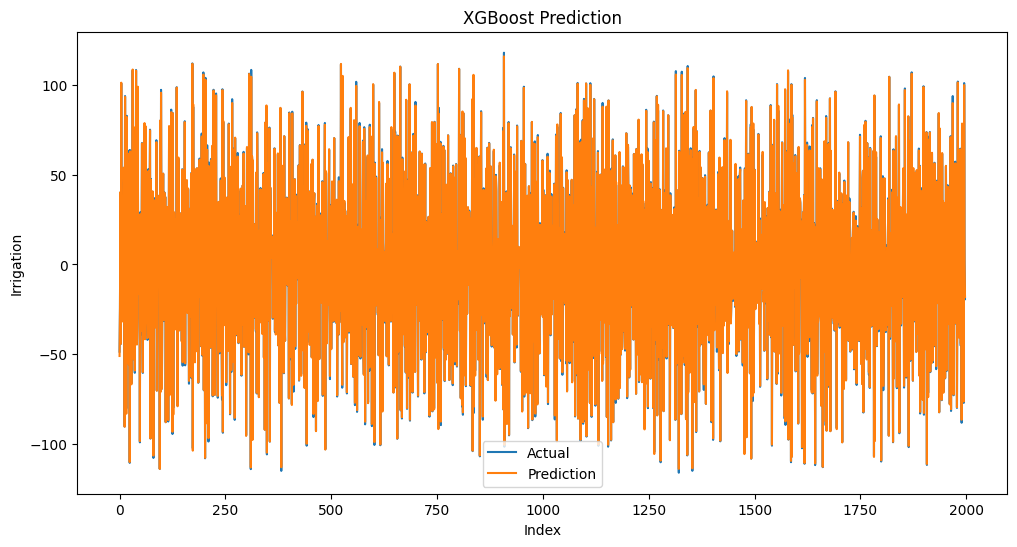

In [154]:
# =========================================================
# 12. VISUALISASI ACTUAL VS PREDICTION
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Prediction')
plt.title("XGBoost Prediction")
plt.xlabel("Index")
plt.ylabel("Irrigation")
plt.legend()
plt.show()


Feature Importance:
                   feature  importance
19                   diff2    0.687273
4   Previous_Irrigation_mm    0.150324
5                     lag1    0.109550
13          rolling_mean_3    0.017030
6                     lag2    0.015764
17           rolling_max_5    0.009929
18           rolling_min_5    0.009538
16           rolling_std_5    0.000110
14          rolling_mean_5    0.000074
7                     lag3    0.000065
10                    lag6    0.000047
9                     lag5    0.000047
3              Rainfall_mm    0.000036
8                     lag4    0.000035
11                    lag7    0.000034
15         rolling_mean_10    0.000034
2                 Humidity    0.000029
0            Soil_Moisture    0.000028
1            Temperature_C    0.000028
12                    lag8    0.000025


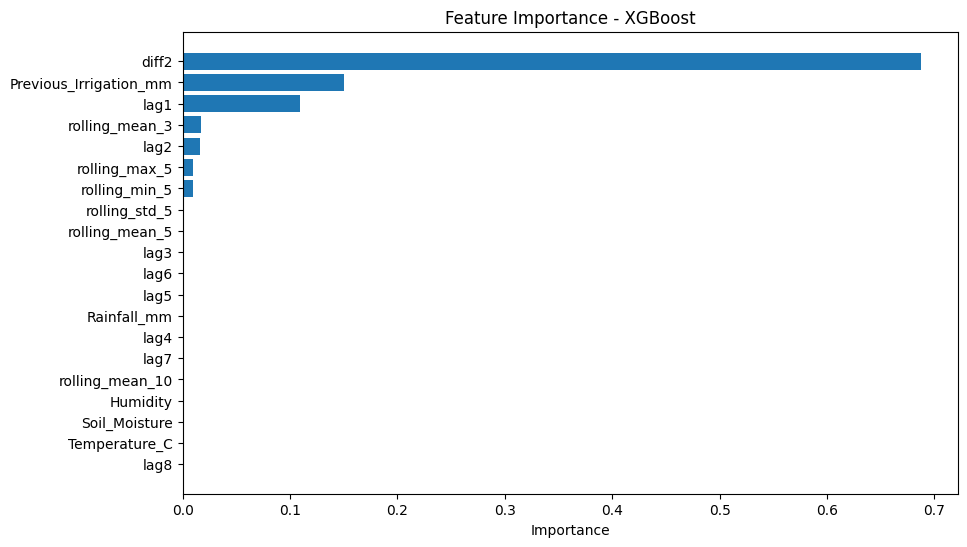

In [155]:
# =========================================================
# 13. FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.show()